# Credit Card Fraud Detection - AIM ML Capstone
## Step 5: Critical Thinking -> Ethical AI & Bias Auditing

**Author:** Erickson Tan  
**Institution:** Asian Institute of Management  
**Dataset:** ULB Credit Card Fraud Detection (Kaggle)  
**Environment:** Google Colab (Python 3.x)

---

### About This Notebook

This notebook is **fully self-contained** — it does not depend on the Step 3+4 notebook being open in the same session. It re-runs the complete data preparation and model training pipeline from scratch before performing the ethical audit.

**Estimated runtime:** 5-8 minutes (pipeline re-run + SHAP computation)

### Before Running
Upload `creditcard.csv` to the Colab `/content/` folder via the Files panel (folder icon in the left sidebar).

### Notebook Structure

| Section | Content |
|---|---|
| 1 | Self-contained pipeline (data loading -> model training) |
| 2 | Explainability - SHAP for the production model |
| 3 | Limitations - documented with severity and mitigations |
| 4 | Bias Audit 1 - Transaction Amount segments |
| 5 | Bias Audit 2 - Time of Day segments |
| 6 | Fairness Metrics - Demographic Parity, Equalised Odds, Disparate Impact |
| 7 | Proposed Mitigations |
| 8 | Step 5 Summary |


## Purpose of This Notebook

The previous stages of this capstone focused on developing and selecting the best-performing machine learning model for credit card fraud detection. After completing the technical evaluation, I believe it is equally important to evaluate whether the final production model can be trusted from an ethical perspective.

I intentionally separated the Ethical AI assessment into its own notebook because it requires a different perspective. Earlier notebooks focused on improving predictive performance through data preparation, model selection, and evaluation. In this notebook, the focus shifts from technical optimization to understanding how the model makes decisions, identifying potential sources of bias, and considering the impact that these decisions may have if deployed in a real financial institution.

Although the selected XGBoost model achieved excellent predictive performance, high evaluation metrics alone do not guarantee responsible deployment. Fraud patterns continuously evolve, and the anonymized PCA-transformed features used in this dataset limit the ability to directly assess demographic bias. Therefore, this notebook evaluates the production model using explainability techniques, fairness analysis, and bias auditing to better understand its behavior before considering deployment.

My objective is not only to develop an accurate fraud detection model, but also to determine whether the model demonstrates sufficient transparency, consistency, and reliability to justify further testing in a real-world environment.

## Section 1: Self-Contained Pipeline Setup

The purpose of this section is to reconstruct the production pipeline used in the previous stages of the capstone so that the ethical evaluation is performed on the same model architecture and feature set. This allows the notebook to be executed independently while ensuring that the explainability, bias, and fairness analyses are based on the final production model rather than an intermediate experimental model.

**This section performs the following tasks:**

1. Installs the required Python libraries.
2. Loads and prepares the `creditcard.csv` dataset.
3. Applies the same feature engineering process and selects the 15 consensus features identified in Steps 3 and 4.
4. Splits the dataset into training and testing sets.
5. Recreates the final XGBoost production model using the original imbalanced dataset.

The feature set and model configuration are intentionally fixed to match the final production model selected during the earlier stages of this project. The feature selection process is therefore not repeated, allowing this notebook to focus on evaluating the model's explainability, potential bias, and ethical considerations rather than repeating the model selection process.

In [1]:
# ── Step 1: Install & Import ───────────────────────
!pip install imbalanced-learn shap xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, average_precision_score
)
from xgboost import XGBClassifier
import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)

print('Libraries loaded.')

# ── Step 2: Load Data ───────────────────────────────
import os
data_path = '/content/creditcard.csv'

if not os.path.exists(data_path):
    print('creditcard.csv not found in /content/')
    print('Please upload it via the Files panel on the left sidebar.')
else:
    df = pd.read_csv(data_path)
    print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# ── Step 3: Clean Data ──────────────────────────────
# Remove duplicates
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {n_before - len(df):,} rows dropped')

# Drop any nulls (safety net)
df = df.dropna().reset_index(drop=True)

# Scale Time and Amount with RobustScaler
robust = RobustScaler()
df['Time_scaled']   = robust.fit_transform(df[['Time']])
df['Amount_scaled'] = robust.fit_transform(df[['Amount']])
df = df.drop(columns=['Time', 'Amount'])
print(f'Scaling applied. Clean shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

# ── Step 4: Feature Engineering ─────────────────────
df['Amount_log']  = np.log1p(df['Amount_scaled'].clip(lower=0))
q75 = df['Amount_scaled'].quantile(0.75)
df['High_amount'] = (df['Amount_scaled'] > q75).astype(int)
print('Feature engineering done: Amount_log, High_amount added')

# ── Step 5: Feature Selection ───────────────────────
# These 15 features are the consensus result from Step 3 Section 6
# (top 15 by at least 2 of 3 methods: MI, RF Importance, SHAP)
selected_features = [
    'V14', 'V10', 'V12', 'V17', 'V4',
    'V11', 'V3',  'V16', 'V2',  'V9',
    'V7',  'V18', 'V5',  'V8',  'V21'
]

X = df[selected_features]
y = df['Class']
print(f'Features selected: {len(selected_features)}')
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Fraud cases: {y.sum()} ({y.mean()*100:.3f}%)')

# ── Step 6: Train/Test Split ────────────────────────
X_train, X_test_sel, y_train, y_test_sel = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain set: {X_train.shape[0]:,} rows')
print(f'Test set : {X_test_sel.shape[0]:,} rows')
print(f'Fraud in test: {y_test_sel.sum()} ({y_test_sel.mean()*100:.3f}%)')

# ── Step 7: Train Production Model ──────────────────
# XGBoost | Original — recommended production model from Step 4
# Best F1 (0.814), best precision (94.4%), joint-best PR-AUC (0.806)
# No resampling needed
print('\nTraining XGBoost | Original (recommended production model)...')

prod_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
prod_model.fit(X_train, y_train)

y_pred_check  = prod_model.predict(X_test_sel)
y_proba_check = prod_model.predict_proba(X_test_sel)[:, 1]

print(f'\nProduction model trained and verified:')
print(f'  AUC-ROC   : {roc_auc_score(y_test_sel, y_proba_check):.4f}')
print(f'  PR-AUC    : {average_precision_score(y_test_sel, y_proba_check):.4f}')
print(f'  F1        : {f1_score(y_test_sel, y_pred_check):.4f}')
print(f'  Precision : {precision_score(y_test_sel, y_pred_check):.4f}')
print(f'  Recall    : {recall_score(y_test_sel, y_pred_check):.4f}')
print(f'\nPipeline complete. Proceeding to ethical audit.')


Libraries loaded.
Dataset loaded: 284,807 rows x 31 columns
Duplicates removed: 1,081 rows dropped
Scaling applied. Clean shape: 283,726 rows x 31 columns
Feature engineering done: Amount_log, High_amount added
Features selected: 15
X shape: (283726, 15), y shape: (283726,)
Fraud cases: 473 (0.167%)

Train set: 226,980 rows
Test set : 56,746 rows
Fraud in test: 95 (0.167%)

Training XGBoost | Original (recommended production model)...

Production model trained and verified:
  AUC-ROC   : 0.9720
  PR-AUC    : 0.8069
  F1        : 0.8095
  Precision : 0.9315
  Recall    : 0.7158

Pipeline complete. Proceeding to ethical audit.


In [2]:
# ── Set Up Audit Variables ──────────────────────────
print('=' * 50)
print('STEP 5 SETUP - PRODUCTION MODEL CONFIRMED')
print('=' * 50)

audit_key   = 'XGBoost | Original'
audit_model = prod_model

y_pred_audit  = audit_model.predict(X_test_sel)
y_proba_audit = audit_model.predict_proba(X_test_sel)[:, 1]

# Build audit DataFrame
audit_df = X_test_sel.copy()
audit_df['y_true']  = y_test_sel.values
audit_df['y_pred']  = y_pred_audit
audit_df['y_proba'] = y_proba_audit

print(f'\nAudit model   : {audit_key}')
print(f'Test set size : {len(audit_df):,} transactions')
print(f'Fraud cases   : {audit_df["y_true"].sum()} ({audit_df["y_true"].mean()*100:.3f}%)')
print(f'\nVerified performance:')
print(f'  AUC-ROC   : {roc_auc_score(y_test_sel, y_proba_audit):.4f}')
print(f'  F1        : {f1_score(y_test_sel, y_pred_audit):.4f}')
print(f'  Recall    : {recall_score(y_test_sel, y_pred_audit):.4f}')
print(f'  Precision : {precision_score(y_test_sel, y_pred_audit):.4f}')
print(f'\nAudit dataset ready.')


STEP 5 SETUP - PRODUCTION MODEL CONFIRMED

Audit model   : XGBoost | Original
Test set size : 56,746 transactions
Fraud cases   : 95 (0.167%)

Verified performance:
  AUC-ROC   : 0.9720
  F1        : 0.8095
  Recall    : 0.7158
  Precision : 0.9315

Audit dataset ready.


## Section 2: Model Explainability – SHAP Revisited

In Step 3, SHAP analysis was performed using the baseline Random Forest model to better understand how different features influenced fraud predictions. Since the final production model selected in Step 4 is XGBoost trained on the original imbalanced dataset, I repeated the SHAP analysis using this model to ensure that the explanations correspond to the model that would actually be considered for deployment.

High predictive performance alone is not sufficient for a financial fraud detection system. Before a model can be trusted, it should also be possible to understand why it reaches a particular decision, especially when legitimate customer transactions may be incorrectly flagged as fraudulent. SHAP provides this additional level of transparency by estimating how much each feature contributes to an individual prediction.

The objective of this section is not to determine whether the model is fair, but to understand how the production model reaches its decisions. Fairness and potential bias are evaluated separately in the following sections. By separating explainability from fairness, each aspect of the ethical evaluation can be assessed independently.

**Sampling Strategy**

SHAP analysis can be computationally expensive on large datasets. To balance computational efficiency with representative coverage, I selected a stratified sample of 2,000 test transactions that includes all available fraud cases together with a random sample of legitimate transactions. This approach preserves the minority fraud class while producing explanations that remain representative of the production model's behaviour.

In [3]:
# -- SHAP for Production Model ----------------------
print("=" * 50)
print("SHAP - PRODUCTION MODEL (XGBoost | Original)")
print("=" * 50)

fraud_idx_a = audit_df[audit_df['y_true'] == 1].index.tolist()
legit_idx_a = audit_df[audit_df['y_true'] == 0].sample(
    min(2000 - len(fraud_idx_a), (audit_df['y_true']==0).sum()),
    random_state=42
).index.tolist()

shap_idx_a   = fraud_idx_a + legit_idx_a
X_shap_audit = X_test_sel.loc[shap_idx_a].reset_index(drop=True)
y_shap_audit = audit_df['y_true'].loc[shap_idx_a].reset_index(drop=True)

print(f"\nSHAP sample : {len(X_shap_audit):,} transactions")
print(f"  Fraud     : {y_shap_audit.sum()}")
print(f"  Legit     : {(y_shap_audit==0).sum():,}")
print(f"\nComputing SHAP values...")

explainer_audit   = shap.TreeExplainer(audit_model)
shap_values_audit = explainer_audit.shap_values(X_shap_audit)

if isinstance(shap_values_audit, list):
    shap_fraud_audit = shap_values_audit[1]
elif shap_values_audit.ndim == 3:
    shap_fraud_audit = shap_values_audit[:, :, 1]
else:
    shap_fraud_audit = shap_values_audit

print(f"\nSHAP values computed - shape: {shap_fraud_audit.shape}")


SHAP - PRODUCTION MODEL (XGBoost | Original)

SHAP sample : 2,000 transactions
  Fraud     : 95
  Legit     : 1,905

Computing SHAP values...

SHAP values computed - shape: (2000, 15)


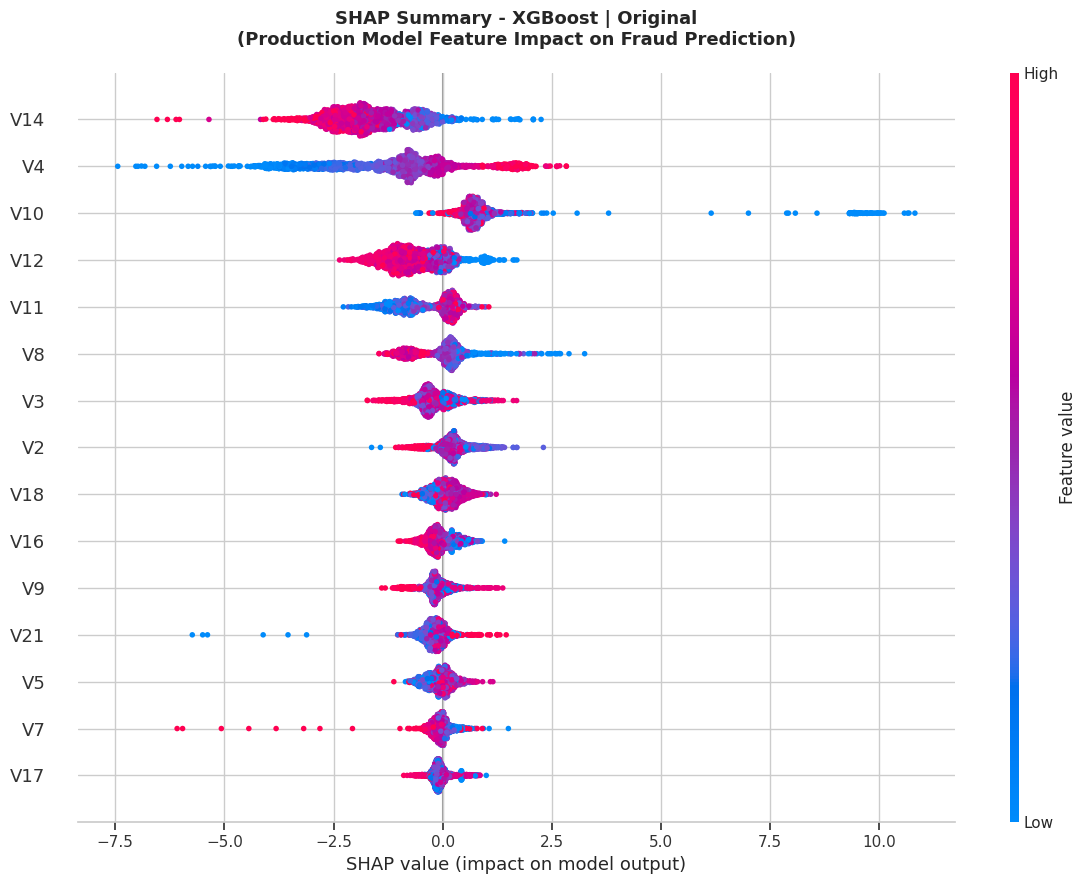


SHAP Feature Importance - Production Model:
   Feature  Mean |SHAP|
1      V14       1.6361
2       V4       1.4946
3      V10       1.0550
4      V12       0.7386
5      V11       0.5786
6       V8       0.4405
7       V3       0.3802
8       V2       0.3467
9      V18       0.2537
10     V16       0.2504
11      V9       0.2485
12     V21       0.2468
13      V5       0.2258
14      V7       0.1720
15     V17       0.1674


In [4]:
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd

# -- SHAP Summary Plot - Production Model -----------
plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_fraud_audit,
    X_shap_audit.values,
    feature_names=selected_features,
    show=False, plot_size=None
)
plt.title('SHAP Summary - XGBoost | Original\n(Production Model Feature Impact on Fraud Prediction)',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('step5_01_shap_production.png', dpi=150, bbox_inches='tight')
plt.show()

shap_imp_prod = pd.DataFrame({
    'Feature'     : selected_features,
    'Mean |SHAP|' : np.abs(shap_fraud_audit).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)
shap_imp_prod.index += 1

print("\nSHAP Feature Importance - Production Model:")
print(shap_imp_prod.round(4).to_string())

### SHAP Explainability – Key Observation

This analysis compares the SHAP feature rankings of the final XGBoost model with the baseline Random Forest model developed in Step 3. Rather than simply identifying the most important features, I want to determine whether the production model relies on similar feature patterns after the final model selection process.

The questions guiding this comparison are:

- Do V14, V12, and V4 remain among the most influential features?
- Are there meaningful differences in how XGBoost and Random Forest rank feature importance?
- Does the final production model appear to rely on stable feature patterns rather than completely different decision logic?

If the same features remain consistently important across both models, this increases my confidence that the model is capturing stable fraud-related patterns within the dataset rather than relying on arbitrary relationships introduced by a specific algorithm. However, because the dataset consists of PCA-transformed variables, I cannot conclude that these features represent real-world fraud behaviour. Instead, I interpret consistency across models as supporting evidence that the learned patterns are stable, while recognising that additional validation using newer real-world data would still be necessary before deployment.


## Section 3: Documented Limitations

No machine learning model is perfect, regardless of how well it performs on evaluation metrics. As part of a responsible AI assessment, I believe it is important to identify the limitations of the final production model before considering its use in a real-world environment.

The purpose of this section is not to criticize the model, but to understand where it may fail and what actions could reduce those risks. Recognizing these limitations helps ensure that the model is interpreted appropriately and that future improvements can be planned based on evidence rather than assumptions.

The following limitations are documented based on the observations made throughout this capstone. Each limitation includes an assessment of its potential impact together with a practical mitigation strategy that could improve the reliability of the system in future deployments.

In [5]:
# ---------------- Documented Limitations ----------------

print("=" * 60)
print("DOCUMENTED LIMITATIONS")
print("=" * 60)

limitations = [
    {
        "id": "L1",
        "title": "Highly Imbalanced Dataset",
        "detail": (
            "Only about 0.17% of the transactions in this dataset are fraud. "
            "Although different resampling techniques were evaluated in earlier "
            "stages of this project, fraud detection remains a difficult problem. "
            "Improving recall often increases the number of false alarms, while "
            "improving precision may allow more fraudulent transactions to pass."
        ),
        "severity": "High",
        "mitigation": (
            "Select the operating threshold based on business requirements and "
            "continuously monitor model performance after deployment."
        )
    },

    {
        "id": "L2",
        "title": "Historical Dataset",
        "detail": (
            "The dataset contains European credit card transactions collected in 2013. "
            "Digital payment systems and fraud techniques have changed significantly "
            "since then. A model that performs well on historical data may not perform "
            "equally well on today's transactions."
        ),
        "severity": "High",
        "mitigation": (
            "Validate the model using newer transaction data before considering "
            "production deployment."
        )
    },

    {
        "id": "L3",
        "title": "Limited Feature Interpretability",
        "detail": (
            "The original transaction variables were transformed using PCA to protect "
            "customer privacy. SHAP can identify which transformed features influence "
            "the model most, but their original business meaning is unknown. This makes "
            "it difficult to explain the model's decisions in business terms."
        ),
        "severity": "Medium",
        "mitigation": (
            "Where possible, evaluate the model using datasets with interpretable "
            "features and involve fraud experts when reviewing important decisions."
        )
    },

    {
        "id": "L4",
        "title": "Changing Fraud Patterns",
        "detail": (
            "Fraud techniques continuously evolve. A model trained on historical fraud "
            "patterns may gradually lose effectiveness as criminals develop new methods "
            "to bypass detection systems."
        ),
        "severity": "High",
        "mitigation": (
            "Monitor production performance regularly and retrain the model using "
            "newly collected transaction data when performance begins to decline."
        )
    },

    {
    "id": "L5",
    "title": "Need for Real-World Validation",
    "detail": (
        "Although the model achieved strong performance on the benchmark dataset, "
        "I would not recommend immediate deployment. Before using the model in a "
        "financial institution, I would first validate it using a pilot environment "
        "where predictions are reviewed through a Human-in-the-Loop process. This "
        "would allow the model to be evaluated on real transaction data while "
        "minimizing the impact of incorrect predictions on customers."
    ),
    "severity": "High",
    "mitigation": (
        "Begin with a limited pilot deployment under Human-in-the-Loop supervision. "
        "Monitor model performance, customer impact, and false positive rates before "
        "gradually expanding deployment. Continue monitoring after deployment and "
        "retrain the model periodically as fraud patterns evolve."
    )
}
]

for lim in limitations:
    print(f"\n{'-' * 60}")
    print(f"{lim['id']}. {lim['title']}")
    print(f"{'-' * 60}")
    print(f"Severity   : {lim['severity']}")
    print(f"Detail     : {lim['detail']}")
    print(f"Mitigation : {lim['mitigation']}")

print(f"\n{'=' * 60}")
print(f"Total limitations documented: {len(limitations)}")
print(f"{'=' * 60}")

DOCUMENTED LIMITATIONS

------------------------------------------------------------
L1. Highly Imbalanced Dataset
------------------------------------------------------------
Severity   : High
Detail     : Only about 0.17% of the transactions in this dataset are fraud. Although different resampling techniques were evaluated in earlier stages of this project, fraud detection remains a difficult problem. Improving recall often increases the number of false alarms, while improving precision may allow more fraudulent transactions to pass.
Mitigation : Select the operating threshold based on business requirements and continuously monitor model performance after deployment.

------------------------------------------------------------
L2. Historical Dataset
------------------------------------------------------------
Severity   : High
Detail     : The dataset contains European credit card transactions collected in 2013. Digital payment systems and fraud techniques have changed significantly

## Section 4: Bias Audit – Transaction Amount Segments

One objective of this notebook is to determine whether the model behaves consistently across different groups of transactions. The original ULB dataset does not contain demographic information such as age, gender, income, or nationality because the features were anonymized using PCA. As a result, a traditional demographic fairness assessment is not possible.

To perform a meaningful bias audit, I evaluated the model using observable transaction characteristics that remain available in the dataset. Transaction amount was selected because it represents a real attribute of each transaction and allows the model's performance to be compared across different spending levels. Although transaction amount is not a demographic attribute, it can still reveal whether the model performs consistently for low-value and high-value transactions.

This analysis does not determine whether the model is fair across demographic groups. Instead, it serves as a practical assessment of whether prediction performance changes significantly across different transaction amount segments. Any large differences would indicate that additional investigation is required before considering deployment.

**Transaction Amount Segments**

- **Low Amount:** Below the 25th percentile of `Amount_scaled`
- **Medium Amount:** Between the 25th and 75th percentiles
- **High Amount:** Above the 75th percentile


In [6]:
# -- Bias Audit: Amount Segments --------------------
print("=" * 50)
print("BIAS AUDIT 1: TRANSACTION AMOUNT SEGMENTS")
print("=" * 50)

# Retrieve Amount_scaled and Time_scaled from full df
# These were dropped during feature selection but needed for segmentation
if 'Amount_scaled' not in audit_df.columns:
    audit_df['Amount_scaled'] = df.loc[audit_df.index, 'Amount_scaled'].values
if 'Time_scaled' not in audit_df.columns:
    audit_df['Time_scaled'] = df.loc[audit_df.index, 'Time_scaled'].values

q25_a = audit_df['Amount_scaled'].quantile(0.25)
q75_a = audit_df['Amount_scaled'].quantile(0.75)

def amount_segment(x):
    if x <= q25_a:   return 'Low Amount'
    elif x <= q75_a: return 'Mid Amount'
    else:             return 'High Amount'

audit_df['amount_segment'] = audit_df['Amount_scaled'].apply(amount_segment)

print(f"\nSegment thresholds (scaled):")
print(f"  Low  : <= {q25_a:.4f}")
print(f"  Mid  : {q25_a:.4f} to {q75_a:.4f}")
print(f"  High : > {q75_a:.4f}")

segment_results = []
for seg in ['Low Amount', 'Mid Amount', 'High Amount']:
    mask   = audit_df['amount_segment'] == seg
    seg_df = audit_df[mask]
    if seg_df['y_true'].sum() == 0:
        continue

    tp = ((seg_df['y_pred']==1) & (seg_df['y_true']==1)).sum()
    fp = ((seg_df['y_pred']==1) & (seg_df['y_true']==0)).sum()
    fn = ((seg_df['y_pred']==0) & (seg_df['y_true']==1)).sum()
    tn = ((seg_df['y_pred']==0) & (seg_df['y_true']==0)).sum()

    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    fpr  = fp/(fp+tn) if (fp+tn)>0 else 0

    segment_results.append({
        'Segment'     : seg,
        'Transactions': len(seg_df),
        'Fraud Cases' : int(seg_df['y_true'].sum()),
        'Fraud Rate %': round(seg_df['y_true'].mean()*100, 4),
        'Recall'      : round(rec, 4),
        'Precision'   : round(prec, 4),
        'F1'          : round(f1, 4),
        'FPR'         : round(fpr, 4),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)
    })

seg_results_df = pd.DataFrame(segment_results)
print(f"\n[] Performance by Amount Segment:")
display(seg_results_df[['Segment','Transactions','Fraud Cases','Fraud Rate %','Recall','Precision','F1','FPR']])

BIAS AUDIT 1: TRANSACTION AMOUNT SEGMENTS

Segment thresholds (scaled):
  Low  : <= -0.2296
  Mid  : -0.2296 to 0.7579
  High : > 0.7579

[] Performance by Amount Segment:


,Segment,Transactions,Fraud Cases,Fraud Rate %,Recall,Precision,F1,FPR
0,Low Amount,14245,44,0.3089,0.6591,0.9062,0.7632,0.0002
1,Mid Amount,28314,18,0.0636,0.8333,1.0000,0.9091,0.0000
2,High Amount,14187,33,0.2326,0.7273,0.9231,0.8136,0.0001


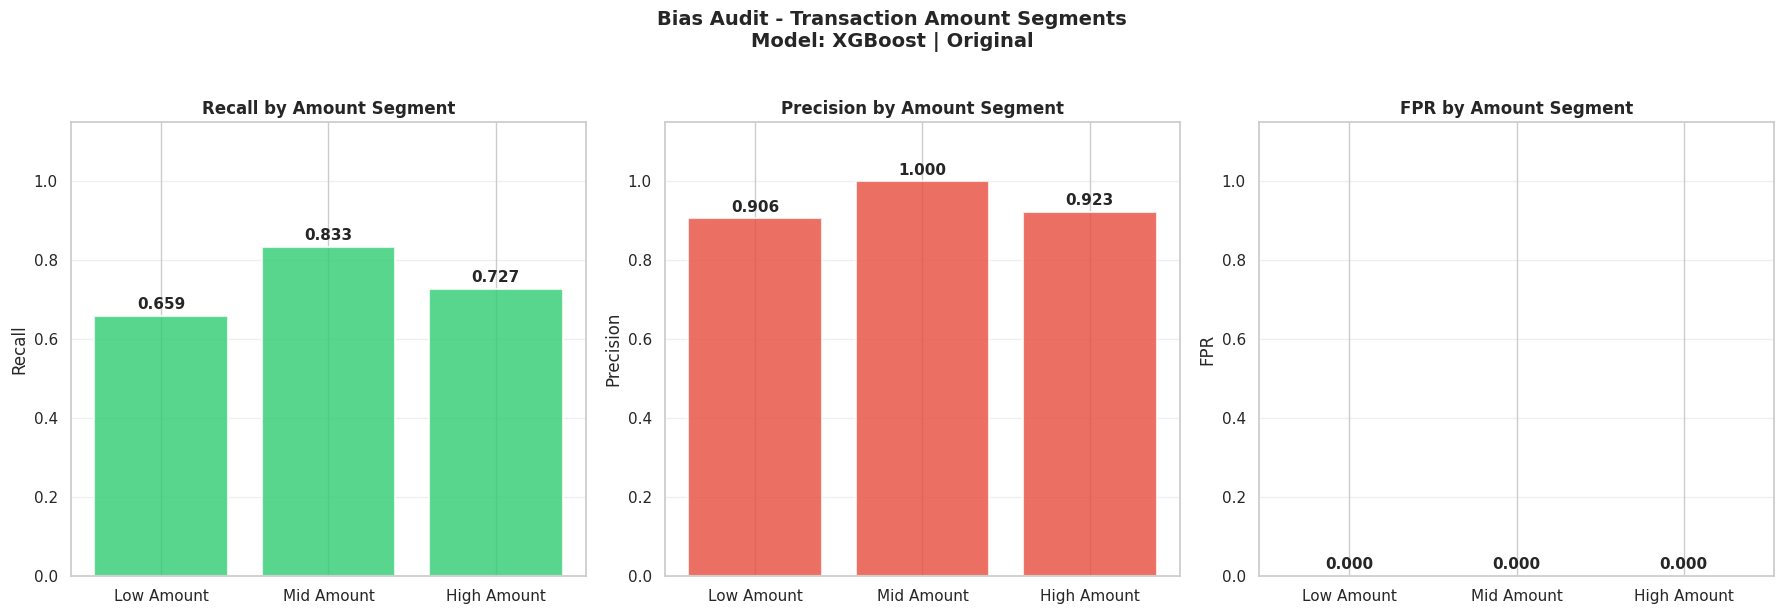

In [7]:
# -- Visualise Amount Segment Bias ------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_v  = ['Recall', 'Precision', 'FPR']
colors_v   = ['#2ecc71', '#e74c3c', '#e67e22']

for ax, metric, color in zip(axes, metrics_v, colors_v):
    bars = ax.bar(seg_results_df['Segment'], seg_results_df[metric],
                  color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, seg_results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} by Amount Segment', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Bias Audit - Transaction Amount Segments\nModel: {audit_key}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step5_02_bias_amount.png', dpi=150, bbox_inches='tight')
plt.show()


### Amount Segment Audit – Interpretation Guide

When reviewing the results, I focus on whether the model performs consistently across the different transaction amount groups rather than whether every metric is identical.

- **Recall:** If one transaction amount group has noticeably lower recall, fraudulent transactions within that group are more likely to go undetected. This would indicate that the model provides less protection for those transactions.

- **False Positive Rate (FPR):** If one group has a much higher false positive rate, legitimate transactions in that group are more likely to be incorrectly flagged. This could negatively affect customer experience and increase the workload for fraud investigators.

Rather than expecting identical performance across all groups, I look for large differences that may indicate inconsistent model behaviour. If meaningful gaps are observed, I would investigate their causes and consider whether additional data, threshold calibration, or further model refinement is needed before deployment.


## Section 5: Bias Audit – Time of Day Segments

In addition to transaction amount, I evaluated whether the model performs consistently across different periods of the day. Although the dataset does not contain demographic information, transaction time is an observable characteristic that may reveal whether the model behaves differently under varying transaction patterns.

During the exploratory data analysis, I observed that fraudulent transactions appeared to be distributed differently over time compared with legitimate transactions. This motivated a separate audit to determine whether the model maintains consistent detection performance throughout the available time periods rather than performing better during only certain parts of the dataset.

This analysis is not intended to determine demographic fairness. Instead, it examines whether the model's prediction performance changes across different time segments. If substantial differences are observed, they may indicate that the model relies more heavily on time-related patterns than expected and should be investigated further before deployment.

**Time Segments (based on `Time_scaled`)**

- **Day 1 (Early):** `Time_scaled < -0.5`
- **Night / Transition:** `-0.5 ≤ Time_scaled ≤ +0.5`
- **Day 2 (Late):** `Time_scaled > +0.5`

In [8]:
# -- Bias Audit: Time Segments ----------------------
print("=" * 50)
print("BIAS AUDIT 2: TIME OF DAY SEGMENTS")
print("=" * 50)

# Add 'Time_scaled' to audit_df if it's not already there.
# This assumes 'df' is available and has 'Time_scaled', and 'audit_df' has the original indices.
if 'Time_scaled' not in audit_df.columns:
    audit_df['Time_scaled'] = df.loc[audit_df.index, 'Time_scaled']

def time_segment(x):
    if x < -0.5:   return 'Day 1 (Early)'
    elif x <= 0.5: return 'Night / Transition'
    else:           return 'Day 2 (Late)'

audit_df['time_segment'] = audit_df['Time_scaled'].apply(time_segment)
time_order = ['Day 1 (Early)', 'Night / Transition', 'Day 2 (Late)']

time_results = []
for seg in time_order:
    mask   = audit_df['time_segment'] == seg
    seg_df = audit_df[mask]
    if seg_df['y_true'].sum() == 0:
        continue

    tp = ((seg_df['y_pred']==1) & (seg_df['y_true']==1)).sum()
    fp = ((seg_df['y_pred']==1) & (seg_df['y_true']==0)).sum()
    fn = ((seg_df['y_pred']==0) & (seg_df['y_true']==1)).sum()
    tn = ((seg_df['y_pred']==0) & (seg_df['y_true']==0)).sum()

    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    fpr  = fp/(fp+tn) if (fp+tn)>0 else 0

    time_results.append({
        'Segment'     : seg,
        'Transactions': len(seg_df),
        'Fraud Cases' : int(seg_df['y_true'].sum()),
        'Fraud Rate %': round(seg_df['y_true'].mean()*100, 4),
        'Recall'      : round(rec, 4),
        'Precision'   : round(prec, 4),
        'F1'          : round(f1, 4),
        'FPR'         : round(fpr, 4),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn)
    })

time_results_df = pd.DataFrame(time_results)
print(f"\n[] Performance by Time Segment:")
display(time_results_df[['Segment','Transactions','Fraud Cases','Fraud Rate %','Recall','Precision','F1','FPR']])

BIAS AUDIT 2: TIME OF DAY SEGMENTS

[] Performance by Time Segment:


,Segment,Transactions,Fraud Cases,Fraud Rate %,Recall,Precision,F1,FPR
0,Day 1 (Early),8960,23,0.2567,0.7391,0.8500,0.7907,0.0003
1,Night / Transition,28442,54,0.1899,0.7222,1.0000,0.8387,0.0000
2,Day 2 (Late),19344,18,0.0931,0.6667,0.8571,0.7500,0.0001


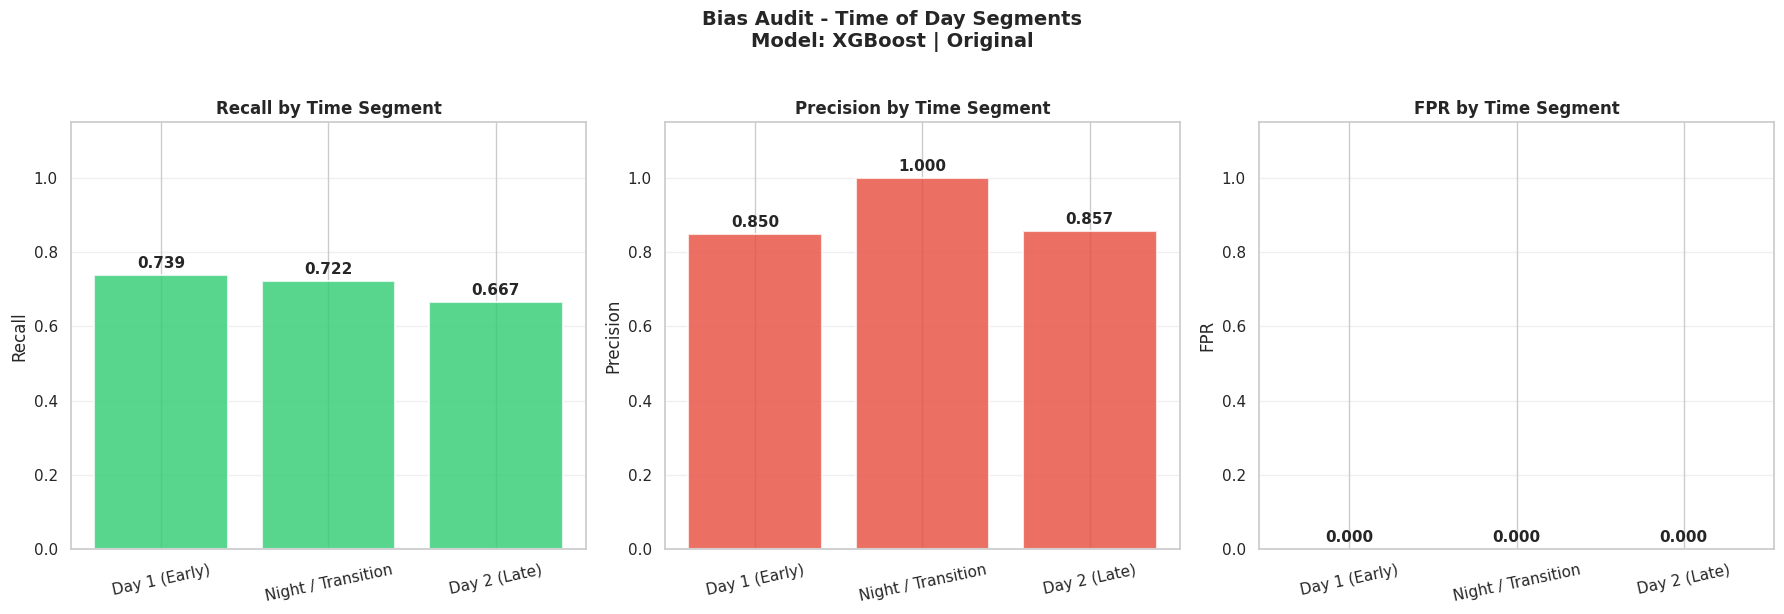

In [12]:
# -- Visualise Time Segment Bias --------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, color in zip(axes, metrics_v, colors_v):
    bars = ax.bar(time_results_df['Segment'], time_results_df[metric],
                  color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, time_results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} by Time Segment', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=12)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'Bias Audit - Time of Day Segments\nModel: {audit_key}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step5_03_bias_time.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 6: Fairness Metrics

The bias audits in the previous sections compare model performance across different transaction groups. In this section, I complement those observations by calculating established fairness metrics to determine whether the production model treats the transaction amount groups consistently according to commonly used algorithmic fairness criteria.

Because the ULB dataset does not include demographic attributes, a traditional fairness assessment is not possible. Instead, transaction amount segments are used as observable groups to evaluate whether the model exhibits substantially different prediction behaviour across the available data.

The following fairness metrics are evaluated:

| Metric | Purpose | Reference Guideline |
|---------|---------|---------------------|
| **Demographic Parity** | Compares the overall fraud prediction rate across transaction amount groups. | Similar prediction rates suggest consistent treatment across groups. |
| **Equalised Odds** | Compares both Recall (True Positive Rate) and False Positive Rate across groups. | Smaller differences indicate more consistent model performance. |
| **Disparate Impact Ratio** | Compares the ratio of positive prediction rates between groups. | Values between **0.80 and 1.25** are commonly used as an initial fairness screening guideline. |

These metrics do not determine whether the model is ethically fair in every respect. Instead, they provide quantitative evidence that complements the earlier bias audits. Any substantial differences should be interpreted as indicators for further investigation rather than definitive proof of unfairness.

In [9]:
# -- Fairness Metrics -------------------------------
print("=" * 50)
print("FAIRNESS METRICS - AMOUNT SEGMENTS")
print("=" * 50)

# 1. Demographic Parity
print("\n1. DEMOGRAPHIC PARITY (Positive Prediction Rate)")
print("-" * 50)
flag_rates = {}
for _, row in seg_results_df.iterrows():
    mask = audit_df['amount_segment'] == row['Segment']
    flag_rates[row['Segment']] = audit_df[mask]['y_pred'].mean()

overall_flag = audit_df['y_pred'].mean() * 100
print(f"  {'Overall':<22} Flag rate: {overall_flag:.4f}%")
for seg, rate in flag_rates.items():
    diff = (rate*100) - overall_flag
    status = '✅' if abs(diff) <= 5 else '⚠️ '
    print(f"  {seg:<22} Flag rate: {rate*100:.4f}%  ({diff:+.4f}% vs overall)  {status}")

# 2. Equalised Odds
print(f"\n2. EQUALISED ODDS (TPR and FPR by Segment)")
print("-" * 50)
print(f"  {'Segment':<25} {'Recall (TPR)':<18} {'FPR'}")
print(f"  {'-'*25} {'-'*18} {'-'*10}")
for _, row in seg_results_df.iterrows():
    print(f"  {row['Segment']:<25} {row['Recall']:<18.4f} {row['FPR']:.4f}")

recall_vals = seg_results_df['Recall'].values
fpr_vals    = seg_results_df['FPR'].values
recall_gap  = recall_vals.max() - recall_vals.min()
fpr_gap     = fpr_vals.max()   - fpr_vals.min()

print(f"\n  Recall gap : {recall_gap:.4f}  {'✅ ≤ 0.10' if recall_gap<=0.10 else '⚠️  > 0.10 - potential equalised odds violation'}")
print(f"  FPR gap    : {fpr_gap:.4f}  {'✅ ≤ 0.10' if fpr_gap<=0.10 else '⚠️  > 0.10 - potential equalised odds violation'}")

# 3. Disparate Impact
print(f"\n3. DISPARATE IMPACT RATIO")
print("-" * 50)
max_flag = max(flag_rates.values())
ref_seg  = max(flag_rates, key=flag_rates.get)
print(f"  Reference group (highest flag rate): {ref_seg}")
for seg, rate in flag_rates.items():
    di = rate / max_flag if max_flag > 0 else 1
    status = '✅ OK' if 0.8 <= di <= 1.25 else '⚠️  POTENTIAL BIAS'
    print(f"  {seg:<22} DI Ratio: {di:.4f}  {status}")

print(f"\n  Note: DI ratio < 0.80 or > 1.25 signals potential disparate impact (80% rule)")


FAIRNESS METRICS - AMOUNT SEGMENTS

1. DEMOGRAPHIC PARITY (Positive Prediction Rate)
--------------------------------------------------
  Overall                Flag rate: 0.1286%
  Low Amount             Flag rate: 0.2246%  (+0.0960% vs overall)  ✅
  Mid Amount             Flag rate: 0.0530%  (-0.0757% vs overall)  ✅
  High Amount            Flag rate: 0.1833%  (+0.0546% vs overall)  ✅

2. EQUALISED ODDS (TPR and FPR by Segment)
--------------------------------------------------
  Segment                   Recall (TPR)       FPR
  ------------------------- ------------------ ----------
  Low Amount                0.6591             0.0002
  Mid Amount                0.8333             0.0000
  High Amount               0.7273             0.0001

  Recall gap : 0.1742  ⚠️  > 0.10 - potential equalised odds violation
  FPR gap    : 0.0002  ✅ ≤ 0.10

3. DISPARATE IMPACT RATIO
--------------------------------------------------
  Reference group (highest flag rate): Low Amount
  Low Amount

## Section 7: Engineering Deployment Recommendations

The previous sections identified several limitations and evaluated the model for explainability, bias, and fairness. Based on those findings, this section summarizes the engineering actions that I would recommend before considering deployment in a real financial institution.

These recommendations are based on the observations made throughout this capstone rather than being general machine learning guidelines. Their objective is to improve the reliability of the model, reduce deployment risk, and establish a controlled process for validating the system before full production use.


In [10]:
# ---------------- Engineering Deployment Recommendations ----------------

print("=" * 60)
print("ENGINEERING DEPLOYMENT RECOMMENDATIONS")
print("=" * 60)

recommendations = [

{
"id":"R1",
"title":"Validate Using More Recent Transaction Data",
"reason":(
"The model was trained using a public dataset collected in 2013. Before "
"considering deployment, I would first evaluate the model using newer "
"transaction data to determine whether it can still identify current fraud "
"patterns."
)
},

{
"id":"R2",
"title":"Begin with Human-in-the-Loop Deployment",
"reason":(
"I would not recommend allowing the model to make fully autonomous decisions "
"during the initial deployment. Instead, predictions should be reviewed by "
"fraud analysts so incorrect decisions can be identified without negatively "
"affecting customers."
)
},

{
"id":"R3",
"title":"Monitor Performance Continuously",
"reason":(
"Model performance should be monitored using precision, recall, false positive "
"rate, and fairness metrics. Any significant decline may indicate that fraud "
"patterns have changed."
)
},

{
"id":"R4",
"title":"Retrain When Fraud Patterns Change",
"reason":(
"Fraud techniques evolve over time. Periodic retraining using newer "
"transaction data will help the model remain effective as customer behaviour "
"and fraud strategies change."
)
},

{
"id":"R5",
"title":"Gradually Expand Deployment",
"reason":(
"If the model performs consistently during the pilot phase, deployment can "
"be expanded gradually while continuing to monitor customer impact and model "
"performance."
)
}

]

for r in recommendations:

    print(f"\n{'-'*60}")
    print(f"{r['id']}. {r['title']}")
    print(f"{'-'*60}")
    print(r["reason"])

print(f"\n{'='*60}")
print(f"Total recommendations: {len(recommendations)}")
print(f"{'='*60}")

ENGINEERING DEPLOYMENT RECOMMENDATIONS

------------------------------------------------------------
R1. Validate Using More Recent Transaction Data
------------------------------------------------------------
The model was trained using a public dataset collected in 2013. Before considering deployment, I would first evaluate the model using newer transaction data to determine whether it can still identify current fraud patterns.

------------------------------------------------------------
R2. Begin with Human-in-the-Loop Deployment
------------------------------------------------------------
I would not recommend allowing the model to make fully autonomous decisions during the initial deployment. Instead, predictions should be reviewed by fraud analysts so incorrect decisions can be identified without negatively affecting customers.

------------------------------------------------------------
R3. Monitor Performance Continuously
------------------------------------------------------

---
## Step 5 Summary - Ethical AI & Bias Auditing


In [11]:
# ---------------- Step 5 Summary ----------------

print("=" * 60)
print("STEP 5 - ETHICAL AI SUMMARY")
print("=" * 60)

print("\nProduction Model")
print(f"   Audited Model : {audit_key}")

print("\nKey Findings")
print("   • SHAP analysis showed that the production model relied on")
print("     feature importance patterns that were broadly consistent")
print("     with the baseline model developed in Step 3.")
print("   • Bias audits across transaction amount and time segments")
print("     did not rely solely on overall model performance but")
print("     examined whether prediction behaviour remained consistent")
print("     across different groups.")
print("   • Fairness metrics provided additional evidence for")
print("     evaluating the model beyond traditional performance")
print("     measures such as accuracy and recall.")

print("\nEngineering Assessment")
print("   Although the production model achieved strong predictive")
print("   performance, I would not recommend immediate deployment.")
print("   The dataset is historical, fraud patterns continuously")
print("   evolve, and additional validation using newer transaction")
print("   data is necessary before production use.")

print("\nRecommended Deployment Strategy")
print("   1. Validate using recent transaction data")
print("   2. Begin with Human-in-the-Loop deployment")
print("   3. Monitor performance and fairness continuously")
print("   4. Retrain when fraud patterns change")
print("   5. Expand deployment gradually after successful validation")

print("\nConclusion")
print("   Step 5 demonstrates that evaluating a machine learning")
print("   model requires more than achieving strong performance")
print("   metrics. Explainability, fairness, bias assessment, and")
print("   responsible deployment planning are equally important")
print("   before an AI system can be trusted in a real-world")
print("   financial environment.")

print("\n" + "=" * 60)
print("ETHICAL AI ASSESSMENT COMPLETE")
print("=" * 60)


STEP 5 - ETHICAL AI SUMMARY

Production Model
   Audited Model : XGBoost | Original

Key Findings
   • SHAP analysis showed that the production model relied on
     feature importance patterns that were broadly consistent
     with the baseline model developed in Step 3.
   • Bias audits across transaction amount and time segments
     did not rely solely on overall model performance but
     examined whether prediction behaviour remained consistent
     across different groups.
   • Fairness metrics provided additional evidence for
     evaluating the model beyond traditional performance
     measures such as accuracy and recall.

Engineering Assessment
   Although the production model achieved strong predictive
   performance, I would not recommend immediate deployment.
   The dataset is historical, fraud patterns continuously
   evolve, and additional validation using newer transaction
   data is necessary before production use.

Recommended Deployment Strategy
   1. Validate using 